**Omega Consulting Analytics Platform**

This notebook serves as the interactive presentation layer for the analytics engine. It orchestrates the ingestion of raw reviews, applies stateless NLP transformations using a hybrid **DistilBERT/VADER** model, extracts explicit **TF-IDF keywords**, and displays tenant-isolated insights and visualizations.

In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)
    sys.path.append(os.path.join(project_root, 'src'))

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scripts.run import execute_etl_run
from src.pipelines.aggregation_reporter import generate_analytics_report
 

load_dotenv()

print(" Pipeline modules successfully imported into the notebook environment.")

 Pipeline modules successfully imported into the notebook environment.


In [3]:
execute_etl_run()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


 Starting ETL Pipeline execution for target: CBE
--------------------------------------------------
[Extract] Pulled 401 rows for CBE (Dropped 399 non-English reviews)
[Transform] Shipping 401 reviews to NLP compute layer...
 [TF-IDF] Top keywords discovered for CBE: ['app', 'good', 'update', 'work', 'application']
 [Verify Schema] Asserted output shapes: 401 rows processed.
 Target Columns Checked: ['review_id', 'review_text', 'sentiment_label', 'sentiment_score', 'identified_theme']
[Load] Enriched asset safely loaded to: c:\Users\Hello\Desktop\kaim\fintech-review-analytics\data/processed\cbe_thematic_reviews.csv
ETL Run Complete for CBE!
--------------------------------------------------

 Starting ETL Pipeline execution for target: Abyssinia
--------------------------------------------------
[Extract] Pulled 430 rows for Abyssinia (Dropped 370 non-English reviews)
[Transform] Shipping 430 reviews to NLP compute layer...
 [TF-IDF] Top keywords discovered for Abyssinia: ['app', 'goo

In [4]:
generate_analytics_report(target_dir="data/processed")


 OMEGA FINTECH ANALYTICS: AGGREGATED SENTIMENT REPORTS

Bank: CBE
-----------------------------------
 Star Rating  Mean Sentiment Confidence
           1                   0.996328
           2                   0.994503
           3                   0.982653
           4                   0.991707
           5                   0.994844
📌 Distinct Business Themes Tracked: 5

Bank: Abyssinia
-----------------------------------
 Star Rating  Mean Sentiment Confidence
           1                   0.996157
           2                   0.996131
           3                   0.978756
           4                   0.983486
           5                   0.994350
📌 Distinct Business Themes Tracked: 5

Bank: Dashen
-----------------------------------
 Star Rating  Mean Sentiment Confidence
           1                   0.995618
           2                   0.996414
           3                   0.993457
           4                   0.988845
           5                   0.99532

In [5]:
user, pw = os.getenv("DB_USER"), os.getenv("DB_PASSWORD")
host, port = os.getenv("DB_HOST"), os.getenv("DB_PORT")
db = os.getenv("DB_NAME")
engine = create_engine(f"postgresql://{user}:{pw}@{host}:{port}/{db}")

print("Database connection successfully established. Ready for extraction.")

Database connection successfully established. Ready for extraction.


In [ ]:
query = """
SELECT r.sentiment_label, r.identified_theme, r.rating, r.review_date, b.bank_name 
FROM reviews r
JOIN banks b ON r.bank_id = b.bank_id
"""
df = pd.read_sql(query, engine)
df['review_date'] = pd.to_datetime(df['review_date'])

print(f" Extracted {len(df)} rows from database for runtime analytics.")
print(df.groupby('bank_name')['rating'].agg(['count', 'mean']).round(2))

 Extracted 1573 rows from database for runtime analytics.
           count  mean
bank_name             
Abyssinia    494  2.90
CBE          494  3.76
Dashen       585  4.06


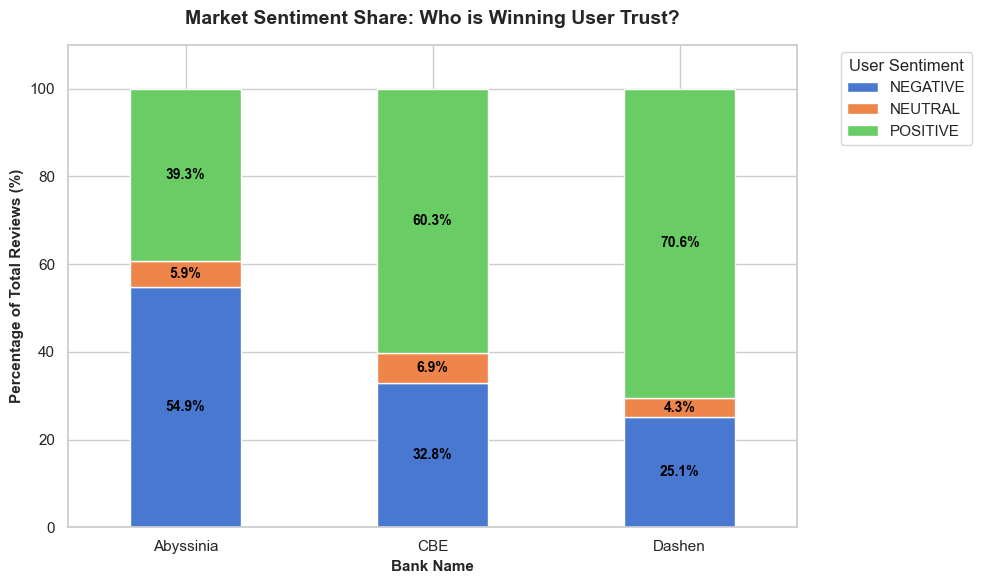

C:\Users\Hello\AppData\Local\Temp\ipykernel_7436\2551478440.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bank_name', y='rating', palette='Set2', width=0.4)


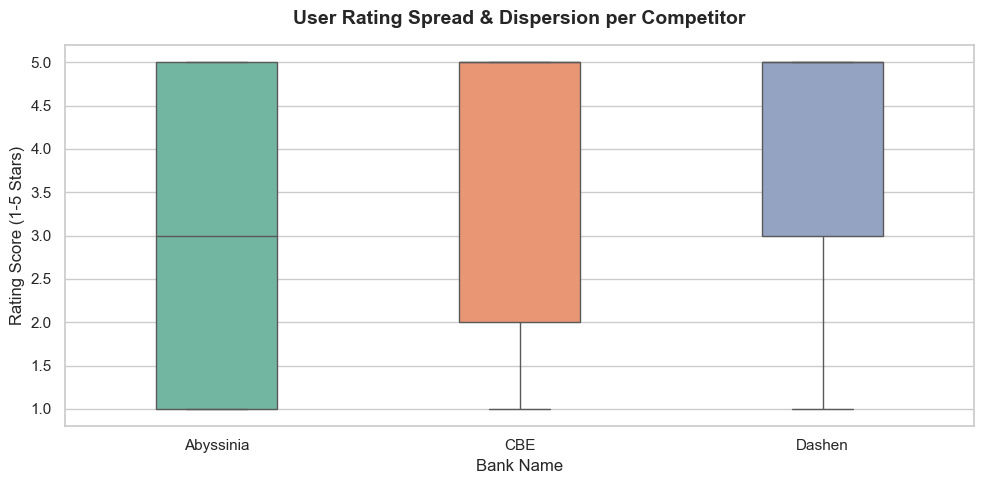

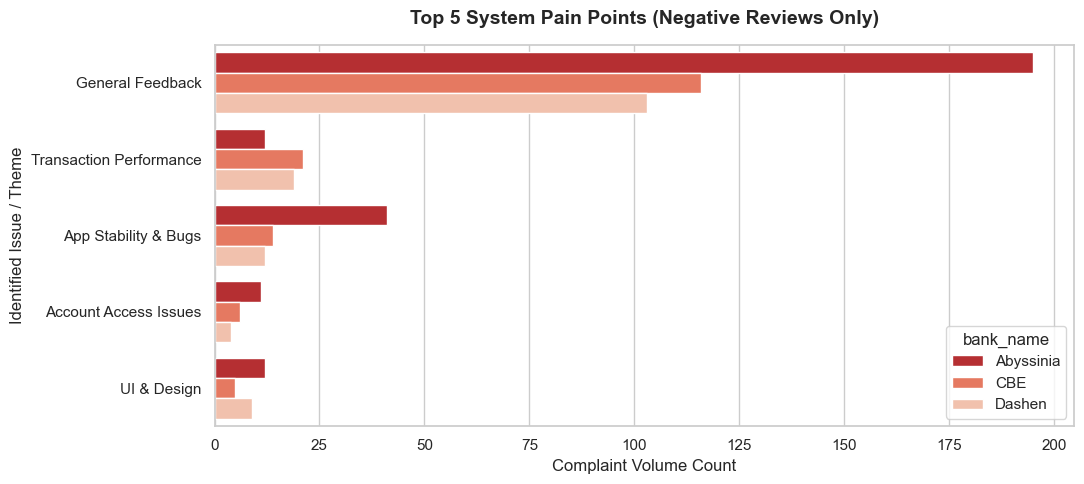

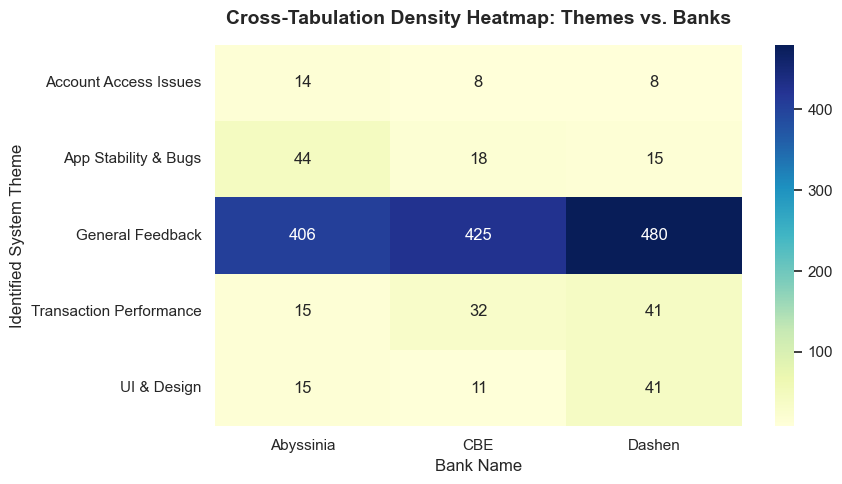

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")

output_dir = os.path.join("..", "data", "plots")
os.makedirs(output_dir, exist_ok=True)

# 1. Sentiment Distribution Breakdown
plt.figure(figsize=(10, 6))
sentiment_pct = df.groupby('bank_name')['sentiment_label'].value_counts(normalize=True).unstack() * 100
sentiment_pct = sentiment_pct[['NEGATIVE', 'NEUTRAL', 'POSITIVE']]
ax = sentiment_pct.plot(kind='bar', stacked=True, ax=plt.gca(), width=0.45)
for container in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 2 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontweight='bold', color='black', fontsize=10)

plt.title('Market Sentiment Share: Who is Winning User Trust?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bank Name', fontweight='bold', fontsize=11)
plt.ylabel('Percentage of Total Reviews (%)', fontweight='bold', fontsize=11)
plt.xticks(rotation=0)
plt.ylim(0, 110) 
plt.legend(title='User Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{output_dir}/sentiment_distribution.png', dpi=300)
plt.show()

# 2. Rating Spread & Dispersion
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='bank_name', y='rating', palette='Set2', width=0.4)
plt.title('User Rating Spread & Dispersion per Competitor', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bank Name')
plt.ylabel('Rating Score (1-5 Stars)')
plt.tight_layout()
plt.savefig(f'{output_dir}/rating_distribution.png', dpi=300)
plt.show()


# 3. Critical Pain Points (Negative Reviews Only)
plt.figure(figsize=(11, 5))
negative_df = df[df['sentiment_label'] == 'NEGATIVE']
top_neg_themes = negative_df['identified_theme'].value_counts().nlargest(5).index
filtered_neg = negative_df[negative_df['identified_theme'].isin(top_neg_themes)]
sns.countplot(data=filtered_neg, y='identified_theme', hue='bank_name', palette='Reds_r')
plt.title('Top 5 System Pain Points (Negative Reviews Only)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Complaint Volume Count')
plt.ylabel('Identified Issue / Theme')
plt.tight_layout()
plt.savefig(f'{output_dir}/sentiment_trend.png', dpi=300)
plt.show()

# 4. Cross-Tabulation Density Heatmap
plt.figure(figsize=(9, 5))
heatmap_data = pd.crosstab(df['identified_theme'], df['bank_name'])
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title('Cross-Tabulation Density Heatmap: Themes vs. Banks', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bank Name')
plt.ylabel('Identified System Theme')
plt.tight_layout()
plt.savefig(f'{output_dir}/theme_intensity_heatmap.png', dpi=300)
plt.show()

### 1. Bank of Abyssinia

* **What the Data Shows:** * Underperforms significantly on user sentiment, with a massive **54.9% Negative Sentiment Share**, the highest among all three competitors.
* The primary culprit is **`App Stability & Bugs`**, which registers **44 critical complaints** (nearly triple the volume of its competitors).
* On a positive note, it maintains a **39.3% Positive Sentiment Ratio**, showing that users are receptive to its baseline feature set when it actually functions.


* **Concrete Recommendations:**
1. **Refactor Session & Login State Machines:** Prioritize an immediate code freeze and engineering sprint focused entirely on fixing the app-crashing bugs during authentication and startup.
2. **Deploy Automated Error Telemetry:** Embed a tool like Firebase Crashlytics or Sentry to automatically capture stack traces on fragmented mobile builds, catching silent runtime exceptions before they cause a hard crash.



###  2. Commercial Bank of Ethiopia (CBE)

* **What the Data Shows:**
* Holds a stable, solid market position with a **60.3% Positive Sentiment Ratio**, backed by high user trust in core transactional utility.
* The leading operational friction point under `Account Access Issues` centers on **version depreciation** (blocking older Android 8/9 builds and Huawei devices) and **forced de-activation loops** that require in-person branch visits to fix after an app update.


* **Concrete Recommendations:**
1. **Optimize Token Persistence Across App Updates:** Engineering should fix session handling so that mandatory app updates don't clear local device authentication data or trigger security locks that force users to visit a branch to re-authenticate.
2. **Introduce Legacy OS Target Builds:** Maintain lighter, backward-compatible API parameters and compile dedicated builds to avoid completely alienating users running older phone architectures or alternative mobile frameworks.



### 3. Dashen Bank

* **What the Data Shows:**
* Emerges as the clear market leader with a commanding **70.6% Positive Sentiment Ratio** and a low negative footstep of just 25.1%.
* Its core advantage lies in **`UI & Design`** (41 entries), indicating that the visual layout and user navigation are highly optimized.
* The primary area for improvement is **`Transaction Performance`**, where it shows a slight spike of **41 complaints** regarding real-time processing and state-sync delays under high traffic loads.


* **Concrete Recommendations:**
1. **Introduce Client-Side Asset Caching:** Keep heavy UI visual assets local to the client app build to minimize network handshake delays, ensuring the interface remains snappy on slow cellular networks.
2. **Isolate Ledger Polling Threads:** Decouple account data-syncing and polling mechanisms from the main UI runtime thread so that backend API delays under heavy traffic cycles never freeze up user interaction.